## Classes

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.special as scp
import json
import jsonpickle
from itertools import product
from matplotlib.ticker import MultipleLocator
from scipy.optimize import curve_fit
np.set_printoptions(suppress=True)


## Functions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.special as scp
import json
import jsonpickle
import scipy.special as scs
from itertools import product
from matplotlib.ticker import MultipleLocator
from scipy.optimize import curve_fit
from scipy.stats import entropy
np.set_printoptions(suppress=True)
sns.set_style("whitegrid")
np.seterr(divide='ignore', invalid='ignore')
np.seterr(over='ignore', invalid='ignore')
sns.set_style("darkgrid")

 class Agent():

	def __init__(self,
				 state_transition_matrix,            # p(s_t|s_t-1)
				 utility,                            # pre-given desirability of observations
				 policies,                           # all possible policies given environment setup
				 prior_rewards,                      # p(s_t|s_t-1)
				 counts_prior_rewards,               # parameters beta of p(phi|beta)
				 prior_policies,                     # p(pi|theta)
				 counts_prior_policies,              # parameters alpha of p(theta|alpha)
				 prior_states,                       # initial p(s|c)
				 prior_context,                      # initial p(c)
				 na,
				 nc,
				 env,
				 approx_pred_pol = True,             # use digamma approx when updating policy prior p(pi|c)
				 approx_pred_rew = True,             # use digamma approx when updating reward posterir p(r|s,c)
				 observation_generation_matrix=None, # p(o_t|s_t)
				 dec_temp = 1,
				 debug=False,
				 context_transition_matrix=None,
				 learn_rewards = False,
				 learn_policies = False,
				 generative_model_cs = None,
				 ac_sel = None
				):
		
		self.na = na
		self.nc = nc

		self.environment = env
		self.action_selection = ac_sel

		self.TAU = env.TAU
		self.T = env.T
		self.nr = env.nr
		self.nc = nc
		self.ns = env.ns
		self.npi = policies.shape[0]
		self.actions = env.actions
		self.rewards = env.rewards
		self.observations = env.observations

		self.generative_model_cs = generative_model_cs
		self.state_transition_matrix = state_transition_matrix
		self.context_transition_matrix = context_transition_matrix
		self.observation_generation_matrix = observation_generation_matrix

		self.utility = utility

		if len(utility.shape) > 1:
			self.changing_preference = True
		else:
			self.changing_preference = False                                        
		
		self.policies = policies
		self.prior_states = prior_states                           
		self.approx_pred_pol = approx_pred_pol
		self.approx_pred_rew = approx_pred_rew
		self.na = na
		self.nc = nc
		self.dec_temp = dec_temp
		
		self.possible_policies = self.policies.copy()
		self.possible_policies_ind = np.arange(self.policies.shape[0])                                 

		self.debug = debug
		self.learn_rewards = learn_rewards
		self.learn_policies = learn_policies

		# belief update logs
		self.posterior_states = np.zeros([self.TAU,self.T, self.ns, self.T, self.npi, self.nc])

		self.prior_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.prior_policies_counts = np.zeros([self.TAU, self.T, self.npi, self.nc])
		if self.learn_policies:
			self.prior_policies[0,:,:,:] = prior_policies
			self.prior_policies_counts[0,:,:,:] = counts_prior_policies[None,:,:]
		else:
			self.prior_policies[:] = prior_policies[None,None,:,:]
			self.prior_policies_counts[:] = counts_prior_policies[None,None,:,:]

		
		self.prior_rewards = np.zeros([self.TAU, self.T] + list(prior_rewards.shape))
		self.prior_rewards[0,:] = prior_rewards[None,:,:,:]

		self.posterior_predictive_rewards = prior_rewards.copy()

		self.prior_rewards_counts = np.zeros(self.prior_rewards.shape)
		self.prior_rewards_counts[0,0] = counts_prior_rewards

		self.dir_rew_params = counts_prior_rewards.copy()

		self.forward_norms = np.zeros([self.TAU, self.T, self.T+1, self.npi, self.nc])
		self.likelihood_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.posterior_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		
		self.prior_context = np.zeros([self.TAU, self.T, self.nc])
		self.prior_context[0,:] = prior_context[None,:]
		self.posterior_context = np.zeros([self.TAU, self.T, self.nc])
		self.policy_entropy = np.zeros([self.TAU, self.T, self.nc])
		# self.outcome_surprise = np.zeros([self.TAU, self.T, self.nc])
		self.policy_surprise = np.zeros([self.TAU, self.T, self.nc])
		self.cs_surprise = np.zeros([self.TAU, self.T, self.nc])
		

	def ln(self, array):
		# array[array==0] = 1e-20
		return np.nan_to_num(np.log(array))


	def linear_ind(self, array):
		
		array = array[:,None].T if array.shape[-1] == 1 else array.T
		return np.ravel_multi_index(array, [self.na]*(self.T-1))


	def digamma_approximation(self, counts):
		return scp.softmax(scp.digamma(counts) - scp.digamma(counts.sum(axis=0)),axis=0)
	
								
	def initialize_states_messages(self,t,tau, active_state):

		# initialize messages for Bethe Approximation Belief Propagation

		self.fwd_messages = np.zeros([self.ns, self.T, self.npi, self.nc]) + 1/self.ns
		self.fwd_messages[:,0,:,:] = self.prior_states[:,None,None]

		self.fwd_norms = np.zeros([self.T+1, self.npi, self.nc])
		self.fwd_norms[0,:,:] = 1                               # accounts for the normalizing constant of the prior

		self.bwd_messages = np.zeros([self.ns, self.T, self.npi, self.nc]) + 1/self.ns
		self.bwd_norms = np.zeros([self.T, self.npi, self.nc])

		self.obs_messages = np.zeros((self.ns, self.T, self.npi, self.nc)) + 1/self.ns

		self.reward_messages = np.zeros([self.ns, self.T, self.npi, self.nc])

		if self.changing_preference:
			util = self.utility[tau]
		else:
			util = self.utility

		# print(tau,t,self.utility)
		# print(tau,t)
		rew_mess = np.einsum('r,rsc -> sc', util, self.posterior_predictive_rewards[:,:,:,active_state])
		# rew_mess /= rew_mess.sum(axis=0)

		self.reward_messages[:] = rew_mess[:,None,None,:]

		# backward message intialization
		for c in range(self.nc):
			for pi, policy in enumerate(self.policies):
				for t, u in zip(np.flip(np.arange(self.T-1)), np.flip(policy)):
					self.bwd_messages[:,t,pi,c] = (self.bwd_messages[:,t+1,pi,c]*self.obs_messages[:,t+1,pi,c]*self.reward_messages[:,t+1,pi,c])\
													.dot(self.state_transition_matrix[:,:,u,active_state])
													
					self.bwd_norms[t,pi,c] = self.bwd_messages[:,t,pi,c].sum()
					self.bwd_messages[:,t,pi,c] /= self.bwd_norms[t,pi,c] 


	def update_states_messages(self,t,tau,pi,policy,c,reward,observation, active_state):
		
		# update rewards messages based on what was observed
		self.reward_messages[:,t,:,:] = self.posterior_predictive_rewards[reward,:,None,:, active_state]

		self.obs_messages[:,t,:,:] = self.observation_generation_matrix[observation,:,None,None]
		
		# perform forward pass
		if (t < self.T-1):
			for tp, u in enumerate(policy):
				self.fwd_messages[:,tp+1,pi,c] = self.state_transition_matrix[:,:,u,active_state]\
												 .dot(self.fwd_messages[:,tp,pi,c]*self.obs_messages[:,tp,pi,c]*self.reward_messages[:,tp,pi,c])
				self.fwd_norms[tp+1,pi,c] = self.fwd_messages[:,tp+1,pi,c].sum() 
				self.fwd_messages[:,tp+1,pi,c] /= self.fwd_norms[tp+1,pi,c]

		# update backward pass based on observed information
		if(t>0):
			for tp, u in zip(np.flip(np.arange(self.T-1)), np.flip(policy)):
				self.bwd_messages[:,tp,pi,c] = (self.bwd_messages[:,tp+1,pi,c]*self.obs_messages[:,tp+1,pi,c]*self.reward_messages[:,tp+1,pi,c])\
												.dot(self.state_transition_matrix[:,:,u,active_state])
				self.bwd_messages[:,tp,pi,c] /= self.bwd_messages[:,tp,pi,c].sum() 


	def update_beliefs_states(self, t, tau, reward, action, observation, active_state):


		if t==0:
			self.possible_policies = self.policies.copy()
			self.possible_policies_ind = np.arange(self.policies.shape[0])

			self.initialize_states_messages(t,tau, active_state)
		
		# check which policies are still possible
		if action is not None:
			self.possible_policies = self.possible_policies[self.possible_policies[:,t-1] == action]
			self.possible_policies_ind = self.linear_ind(self.possible_policies)
			
		for c in range(self.nc):
			for pi, policy in enumerate(self.policies):
				if pi in self.possible_policies_ind:
					# for tp, u in enumerate(policy):
					self.update_states_messages(t, tau, pi, policy, c, reward, observation, active_state)
				else:
					self.fwd_messages[:,:,pi,:] = 0
					self.fwd_norms[:,pi,:] = 0

		post  = self.fwd_messages*self.bwd_messages*self.obs_messages*self.reward_messages
		post_norm = post.sum(axis=0)
		post = np.nan_to_num(post/post_norm)

		self.fwd_norms[-1,:,:] = post_norm[-1,:,:]
		self.forward_norms[tau,t] = self.fwd_norms
		self.posterior_states[tau,t,:,:,:,:] = post

		return post
	

	def update_beliefs_policies(self,t,tau):
		
		likelihood = self.fwd_norms.prod(axis=0)                      # exp(log(norms)) = -F(pi,c) 
		posterior_policies  = np.power(likelihood, self.dec_temp) * self.prior_policies[tau,t]   # exp(digamma(alpha_ij) - digamma(alpha_j)) when you integrate theta out
		posterior_policies /= posterior_policies.sum(axis=0)
		
		# store in global log
		self.likelihood_policies[tau,t] = likelihood/likelihood.sum(axis=0)
		self.posterior_policies[tau,t] = posterior_policies


		return likelihood, posterior_policies
	

	def update_beliefs_context(self,t,tau, likelihood_policies, posterior_policies, prior_context, cs, active_state):
	
		# print(tau,t)
		
		if t>0:
			alphas = self.prior_policies_counts[tau,t].copy()
			chosen_pol = np.argmax(posterior_policies[:,0])
			alpha_prime = alphas.copy()
			alpha_prime[chosen_pol,:] += prior_context
			outcome_surprise =   (posterior_policies * self.ln(likelihood_policies)).sum(axis=0)
			policy_entropy   =  -(posterior_policies * self.ln(posterior_policies)).sum(axis=0)
			policy_surprise  =   (posterior_policies * (scp.digamma(alpha_prime) - scp.digamma(alpha_prime.sum(axis=0)))).sum(axis=0)# (posterior_policies * scp.digamma(alphas)).sum(axis=0) - scp.digamma(alphas.sum(axis=0)) #

		else:
			outcome_surprise = np.array([0]*self.nc)
			policy_entropy   = np.array([0]*self.nc)
			policy_surprise  = np.array([0]*self.nc)
			
		cs_surprise = self.generative_model_cs[cs,:]
		
		posterior_context = policy_entropy + policy_surprise + self.ln(prior_context)  + self.ln(cs_surprise) # + outcome_surprise
						   
		posterior_context = np.nan_to_num(scp.softmax(posterior_context))


		if self.debug:
			print('\n'f"tau: {tau}, reward: {self.rewards[tau,t]}, action: {self.actions[tau]}, cs: {cs}, active state: {active_state}")
			print('outcome_surprise')
			print(outcome_surprise.round(3))
			print('policy_entropy')
			print(policy_entropy.round(3))
			print('policy_surprise')
			print(policy_surprise.round(3))
			print('cs_surprise')
			print(self.ln(cs_surprise).round(3))
			print('prior_context')
			print(self.ln(prior_context).round(3))
			print('posterior context')
			print(posterior_context.round(3))
		
		# print(posterior_context)
		self.posterior_context[tau,t] = posterior_context
		self.policy_surprise[tau,t] = policy_surprise
		self.policy_entropy[tau,t] = policy_entropy
		# self.outcome_surprise[tau,t] = outcome_surprise
		self.cs_surprise[tau,t] = cs_surprise
		# self.background_color_surprise[tau,t] = color_surprise

		return posterior_context
	

	def update_beliefs_prior_rewards(self,t,tau,reward,posterior_states, posterior_policies, posterior_context, active_state):
		post_state = np.einsum('spc,pc->sc', posterior_states[:,t,:,:], posterior_policies)
		# post_pol = posterior_policies.dot(posterior_context)
		# post_state = posterior_states[:,t,:].dot(post_pol)
		state = np.argmax(post_state,axis=0)

		beta = self.dir_rew_params.copy()
		beta_prime = beta.copy()
		beta_prime[reward,state,-1,active_state] += 1

		self.prior_rewards_counts[tau,t] = beta_prime

		if self.approx_pred_rew:
			posterior_predictive_rewards = self.digamma_approximation(beta_prime)
		else:
			posterior_predictive_rewards = beta_prime / beta_prime.sum(axis=0) 

		self.prior_rewards[tau,t] = posterior_predictive_rewards

		return posterior_predictive_rewards, beta_prime


	def update_beliefs_prior_policies(self,t,tau, posterior_context):
		
		pol_ind = self.linear_ind(self.actions[tau])[0]
		alphas = self.prior_policies_counts[tau,t].copy()
		alphas_prime = alphas.copy()
		alphas_prime[pol_ind,:] += posterior_context
		self.prior_policies_counts[tau+1] = alphas_prime[None,:,:]

		if self.approx_pred_pol:
			posterior_predictive_policies = self.digamma_approximation(alphas_prime)
		else:
			posterior_predictive_policies = alphas_prime / alphas_prime.sum(axis=0)
		

		self.prior_policies[tau+1] = posterior_predictive_policies[None,:,:]
		
		# print('\n',tau, ', action: ', self.actions[tau][0])
		# print(posterior_context)
		# print(alphas_prime)
		# print(posterior_predictive_policies)


	def update_beliefs(self, t, tau, state, reward, action, observation, cs, active_state):
		
		posterior_states = self.update_beliefs_states(t, tau, reward, action, observation, active_state)
		
		likelihood_policies, posterior_policies = self.update_beliefs_policies(t,tau)


		if t == 0 and tau != 0:
			prior_context = self.posterior_context[tau-1,-1]
			self.prior_context[tau] = self.context_transition_matrix.dot(prior_context)

		prior_context = self.prior_context[tau,t]
		posterior_context = self.update_beliefs_context(t,tau, likelihood_policies, posterior_policies, prior_context, cs, active_state)


		if self.learn_rewards:
			self.posterior_predictive_rewards, self.dir_rew_params = self.update_beliefs_prior_rewards(t,tau,reward, posterior_states,
																		posterior_policies,posterior_context, active_state)

		if (t == self.T-1 and tau < self.TAU-1 and self.learn_policies):
			self.update_beliefs_prior_policies(t, tau, posterior_context)


		if False:
		# if tau < self.TAU - 1 and self.debug:
			print(f"--------------------\ntau,t: {tau,t}")
			print(f"action: {action}, observation: {observation}, reward: {reward}, cs: {cs}, active_state: {active_state}")


			print(f"\nq(R|pi,c); policy likelihood:")
			print(likelihood_policies.round(3))

			print(f"q(pi|c) policy posterior:")
			print(posterior_policies.round(3))
			
			print(f"\nposterior_context:")
			print(posterior_context.round(3))


			if t == self.T-1:

				print(f"\nrewards counts:")
				print(f"obs, reward: {observation, reward}")
				for k in range(self.prior_rewards.shape[-1]):
					print(f"\n{self.prior_rewards_counts[tau,t,:,:,-1,k].round(3)}")
				
				# print(f"prior_rewards")
				# for k in range(self.prior_rewards.shape[-1]):
				# 	print(self.prior_rewards[tau,t,:,:,k].round(3))


	def sample_action(self,t,tau):
		#get response probability
		posterior_policies = np.einsum('pc,c->p', self.posterior_policies[tau, t], self.posterior_context[tau, 0])
		posterior_policies /= posterior_policies.sum()
		avg_likelihood = np.einsum('pc,c->p', self.likelihood_policies[tau,t], self.posterior_context[tau, 0])
		avg_likelihood /= avg_likelihood.sum()
		prior = np.einsum('pc,c->p', self.prior_policies[tau-1,t], self.posterior_context[tau, 0])
		prior /= prior.sum()
		controls = self.policies[:, t]#[non_zero]


		self.actions[tau, t] = self.action_selection.select_desired_action(tau,
										t, posterior_policies, controls, avg_likelihood, prior)


		return self.actions[tau, t]

		# post_policies = self.posterior_policies[tau,t]
		# post_context = self.posterior_context[tau,t]

		# post_policies = post_policies.dot(post_context)
		# # chosen_action = self.policies[np.argmax(post_policies)][t]
		
		# post_actions = np.zeros(self.na)
		# for a in range(self.na):
		# 	post_actions[a] = post_policies[self.policies[:,t] == a].sum()

		# chosen_action = np.random.choice(np.arange(self.na), p=post_actions)
		# self.actions[tau,t] = chosen_action
		
		# return chosen_action


class DirichletSelector(object):

	def __init__(self, trials = 1, T = 10, number_of_actions = 2, factor=0.1, calc_dkl=False, calc_entropy=False, draw_true_post=True):
		self.n_pars = 0

		self.na = number_of_actions
		self.control_probability = np.zeros((trials, T, self.na))
		self.RT = np.zeros((trials, T-1))
		self.policy_counts = np.zeros((trials,number_of_actions))
		self.factor = factor
		self.draw_true_post = draw_true_post

		self.calc_dkl = calc_dkl
		if calc_dkl:
			self.DKL_post = np.zeros((trials, T-1))
			self.DKL_prior = np.zeros((trials, T-1))
		self.calc_entropy = calc_entropy
		if calc_entropy:
			self.entropy_post = np.zeros((trials, T-1))
			self.entropy_prior = np.zeros((trials, T-1))
			self.entropy_like = np.zeros((trials, T-1))


	def logBeta(self, a):
		return scs.loggamma(a).sum() - scs.loggamma(a.sum())


	def reset_beliefs(self):
		self.control_probability[:,:,:] = 0


	def set_pars(self, pars):
		pass


	def log_prior(self):
		return 0


	def select_desired_action(self, tau, t, posterior_policies, actions, *args):

		npi = posterior_policies.shape[0]
		likelihood = args[0]
		prior = args[1] #np.ones_like(likelihood)/npi #
		# likelihood = np.array([0.5,0.5])
		# prior = np.array([0.5,0.5])
		# posterior_policies = prior * likelihood
		# posterior_policies /= posterior_policies.sum()
		# print(prior, likelihood, posterior_policies)
		self.accepted_pis = np.zeros(100000, dtype=np.int32) - 1
		dir_counts = np.ones(npi, np.double)

		curr_ess = 0
		i = 0

		H_0 =         + (dir_counts.sum()-npi)*scs.digamma(dir_counts.sum()) \
						- ((dir_counts - 1)*scs.digamma(dir_counts)).sum() \
						+ self.logBeta(dir_counts)
		#print("H", H_0)

		pi = np.random.choice(npi, p=prior)
		self.accepted_pis[i] = pi
		dir_counts[pi] += 1
		H_dir =         + (dir_counts.sum()-npi)*scs.digamma(dir_counts.sum()) \
						- ((dir_counts - 1)*scs.digamma(dir_counts)).sum() \
						+ self.logBeta(dir_counts)
		#print("H", H_dir)
		dir_counts_log = np.zeros([100000, npi])
		if t == 0:
			i += 1
			while H_dir>H_0 - self.factor + self.factor*H_0:

				pi = np.random.choice(npi, p=prior)
				r = np.random.rand()
				#print(i, curr_ess)

				#acc_prob = min(1, posterior_policies[pi]/posterior_policies[self.accepted_pis[i-1]])
				if likelihood[self.accepted_pis[i-1]]>0:
					acc_prob = min(1, likelihood[pi]/likelihood[self.accepted_pis[i-1]])
				else:
					acc_prob = 1
				if acc_prob >= r:#posterior_policies[pi]/posterior_policies[self.accepted_pis[i-1]] > r:
					self.accepted_pis[i] = pi
					dir_counts[pi] += 1#acc_prob
				else:
					self.accepted_pis[i] = self.accepted_pis[i-1]
					dir_counts[self.accepted_pis[i-1]] += 1#1-acc_prob
				dir_counts_log[i] = dir_counts
				H_dir =     + (dir_counts.sum()-npi)*scs.digamma(dir_counts.sum()) \
							- ((dir_counts - 1)*scs.digamma(dir_counts)).sum() \
							+ self.logBeta(dir_counts)
				#print("H", H_dir)

				i += 1

			dir_counts_log /= dir_counts_log.sum(axis=1)[:,None]
			# plt.figure()
			# sns.lineplot(x=np.arange(i), y=dir_counts_log[:i,0])
			# sns.lineplot(x=np.arange(i), y=dir_counts_log[:i,1])
			# plt.hlines(posterior_policies[0], '--', xmax=i, alpha=0.5, color="gray")

			self.RT[tau,t] = i-1
			self.policy_counts[tau] = dir_counts
			#print(tau, t, i-1)
		else:
			self.RT[tau,t] = 0

		# print(f"tau,t,smaples: {tau},{t},{i}")
		# print(dir_counts/dir_counts.sum())
		# print(posterior_policies)

		if self.draw_true_post:
			chosen_pol = np.random.choice(npi, p=posterior_policies)
		else:
			chosen_pol = self.accepted_pis[i-1]

		u = actions[chosen_pol]
		#print(tau,t,iself.accepted_pis[i-1],u,H_rel)
		# if tau in range(100,110) and t==0:
		#     plt.figure()
		#     plt.plot(posterior_policies)
		#     plt.show()

		if self.calc_dkl:
			# autocorr = acov(self.accepted_pis[:i+1])

			# if autocorr[0] > 0:
			#     ACT = 1 + 2*np.abs(autocorr[1:]).sum()/autocorr[0]
			#     ess = i/ACT
			#     ess = round(ess)
			# else:
			#     ess = 1

			dist = dir_counts / dir_counts.sum()
			D_KL = entropy(posterior_policies, dist)
			self.DKL_post[tau,t] = D_KL
			D_KL = entropy(prior, dist)
			self.DKL_prior[tau,t] = D_KL

		if self.calc_entropy:
			self.entropy_post[tau,t] = entropy(posterior_policies)
			self.entropy_prior[tau,t] = entropy(prior)
			self.entropy_like[tau,t] = entropy(likelihood)
			# if t==0:
			#     print(tau)
			#     n = 12
			#     ind = np.argpartition(posterior_policies, -n)[-n:]
			#     print(np.sort(ind))
			#     print(np.sort(posterior_policies[ind]))

		#estimate action probability
		self.estimate_action_probability(tau, t, posterior_policies, actions)

		return u


	def estimate_action_probability(self, tau, t, posterior_policies, actions, *args):

		#estimate action probability
		control_prob = np.zeros(self.na)
		for a in range(self.na):
			control_prob[a] = posterior_policies[actions == a].sum()


		self.control_probability[tau, t] = control_prob


class PIT_task():

	def __init__(self,
				 state_transition_matrix,
				 reward_generation_matrix,
				 T=2,
				 n_bandits=2,
				 observation_generation_matrix=None, no=None,
				 TAU=90, nshells=6, ncs=5, shell_valence=np.array([-1,-1,-1,1,1,1]), cs_valence=np.array([-2,-1,0,1,2])):

		self.TAU = TAU
		self.nshells = nshells
		self.ncs = ncs
		self.shell_valence = shell_valence
		self.cs_valence = cs_valence

		self.Rho = reward_generation_matrix
		self.B = state_transition_matrix
		self.nr, self.ns, self.TAU = reward_generation_matrix.shape
		self.na =  self.B.shape[-1]
		self.states  = np.zeros([TAU,T],dtype=int)
		self.rewards = np.zeros([TAU,T],dtype=int)
		self.actions = np.zeros([TAU, T-1],dtype=int)
		self.observations = np.zeros([TAU,T],dtype=int)
		self.active_state = np.zeros(TAU, dtype=int)
		self.cs = np.zeros(TAU, dtype=int)
		

		if observation_generation_matrix is None:
			self.observation_generation_matrix = np.eye(self.ns)
			self.no = self.ns
		else:
			self.observation_generation_matrix = observation_generation_matrix
			self.no = no

		self.TAU = TAU
		self.T = T

	
	def generate_trials(self):
		cs_trials = self.TAU//self.ncs
		shell_x_cs_trials = cs_trials//self.nshells

		trials = np.zeros([self.TAU, 3], dtype=int)
		trials[:,0] = np.arange(self.ncs).repeat(cs_trials)
		trials[:,1] = np.tile(np.arange(self.nshells).repeat(shell_x_cs_trials),self.ncs)
		
		congruence = np.zeros([self.TAU,2], dtype=int)
		congruence[:,0] = self.cs_valence[trials[:,0]]
		congruence[:,1] = self.shell_valence[trials[:,1]]
		congruence = congruence.prod(axis=1)
		congruence[congruence > 0] = 1
		congruence[congruence < 0] = -1
		trials[:,2] = congruence
		np.random.shuffle(trials)

		self.trials = trials

	
	def sample_reward(self, t, tau, state):
		shell = self.active_state[tau]
		self.rewards[tau,t] = np.random.choice(np.arange(self.nr), p=self.Rho[:,state,shell])
		return self.rewards[tau,t]


	def sample_shell(self, t, tau):
		self.active_state[tau] = self.trials[tau,1]
		return self.active_state[tau]


	def sample_cs(self, t, tau):
		self.cs[tau] = self.trials[tau,0]
		return self.cs[tau]


	def sample_hidden_state(self, t, tau, action,active_state):
		self.actions[tau,t-1] = action
		self.states[tau,t] = np.random.choice(np.arange(self.ns), p=self.B[:,self.states[tau, t-1], action, active_state])
		
		return self.states[tau,t]
	
	
	def generate_observation(self, t, tau, state):

		self.observations[tau,t] = np.random.choice(np.arange(self.no), p=self.observation_generation_matrix[:,state])
		return self.observations[tau,t]
	

	def initialize_hidden_state(self, tau, starting_state=2):
		self.states[tau,0] = starting_state
		return starting_state


class World():


	def __init__(self, agent, environment,training_protocol=None):

		self.environment = environment
		self.agent = agent
		# self.perc - self.agent.perc
		self.TAU = environment.TAU
		self.T = environment.T
		self.nr = environment.nr


	def simulate_belief_update(self, actions, rewards, observations):

		for tau in range(self.TAU):
			for t in range(self.T):
				if t == 0:
					action=None
					state = observations[tau,t]
				else:
					state = observations[tau,t]

				observation = observations[tau,t]

				reward = rewards[tau,t]
				
				self.agent.update_beliefs(t, tau, state, reward, action, observation)

				if t < self.T-1:
					action = actions[tau,0]


	def simulate_experiment(self, TAU=None):

		for tau in range(self.TAU):
			for t in range(self.T):
				if t == 0:
					action=None
					state = self.environment.initialize_hidden_state(tau)
					cs = self.environment.sample_cs(t, tau)
					active_state = self.environment.sample_shell(t, tau)

				else:
					active_state = self.environment.active_state[tau]
					state = self.environment.sample_hidden_state(t, tau, action, active_state)
					cs = self.environment.cs[tau]

				observation = self.environment.generate_observation(t,tau,state)

				reward = self.environment.sample_reward(t, tau, state)


				
				self.agent.update_beliefs(t, tau, state, reward, action, observation, cs, active_state)

				if t < self.T-1:
					action = self.agent.sample_action(t,tau)

				# if t == self.T-1:
				#     perc = self.agent.perc
				#     for c in range(perc.k):
				#         print(f"\n\ntrial: {tau}, t: {t}, context: {c}")
				#         print(f"action: {action}, reward: {reward}")
				#         print(f"\npost_states:\n{perc.posterior_states[tau,t,:,:,action,c]}")
				#         print(f"\nprior_context:\n{perc.prior_context[tau,t].round(3)}")
				#         print(f"\nposterior_context:\n{perc.posterior_context[tau,t].round(3)}")
				#         print(f"\nprior_rewards:\n{perc.prior_rewards_counts[tau+1,t,:,:,c].round(3)}")
				#         print(f"\nprior_policies:\n{perc.prior_policies_counts[tau+1,t,:,c].round(3)}")
				
				#     if tau==103:
				#         a=0


def run_simulation(TAU=90, rep=1, na=2, nshells=6, nr=3, ncs=5, T=2, approx_pred_pol = True, approx_pred_rew = True,
				   utility = np.array([0.01,0.98, 0.01]), bias=1, Rho = None, debug=False, context_volatility=0.98, cs_volatility=0.98,
				   shell_valence=np.array([-1,-1,-1, 1, 1, 1]), cs_valence=np.array([-2,-1,0,1,2]), learn_rewards=True, decision_factor=0.4):
	
	nb = 2
	ns = nb+1
	nc = ncs+1

	
	'''           define policies            '''
	npi = na**(T-1)
	# policies = list(product(list(np.arange(na))*(T-1)))
	policies = np.array(list(product( np.arange(na), repeat= T-1)))



	'''       define p(s_t|s_t-1, a_t-1)      '''
	prior_states = np.array([0]*nb + [1])
	state_transition_matrix = np.zeros([ns,ns,na])

	for b in range(na):
		state_transition_matrix[b,:,b] = 1
	
	state_transition_matrix = np.stack([state_transition_matrix]*nshells,axis=-1)

	
	'''          define p(o_t|s_t)            '''
	observation_generation_matrix = np.eye(ns)
	

	'''           define p(r|s)             '''
	good_shell_contingencies =  np.array([[80, 20, 1],     # s0 -> shell not taken, s1 -> shell taken
										  [20, 80, 1],     # r0 -> no reward  , r1 -> reward
										  [0, 0, 100]])
	
	bad_shell_contingencies  =  np.array([[20, 80, 1],    
										  [80, 20, 1],
										  [0, 0, 100]])
	
	uniform_contingencies   =   np.array([[1, 1,   1],     # s0 -> shell not taken, s1 -> shell taken
										  [1, 1,   1],     # r0 -> no reward  , r1 -> reward
										  [0, 0, 100]])
	# good_shell_contingencies = np.stack([np.ones([nr,na+1])]*ncs + [good_shell_contingencies], axis=-1)
	# bad_shell_contingencies  = np.stack([np.ones([nr,na+1])]*ncs + [bad_shell_contingencies], axis=-1)

	good_shell_contingencies = np.stack([uniform_contingencies]*ncs + [good_shell_contingencies], axis=-1)
	bad_shell_contingencies  = np.stack([uniform_contingencies]*ncs + [bad_shell_contingencies], axis=-1)

	counts_prior_rewards = np.stack([bad_shell_contingencies]*3 + [good_shell_contingencies]*3, axis=-1)
	prior_rewards = counts_prior_rewards / counts_prior_rewards.sum(axis=0)


	'''              define p(pi|c)           '''
	counts_prior_policies = np.ones([npi,nc])
	for pi in range(npi):
		ind = np.arange(pi*3,(1+pi)*3) - pi
		counts_prior_policies[pi, ind] += bias*np.abs(cs_valence)[ind]

	# print(counts_prior_policies)
	prior_policies = counts_prior_policies / counts_prior_policies.sum(axis=0)


	'''       define CS generative model p(cs|c) '''
	p = cs_volatility
	generative_model_cs = np.ones([ncs,nc])*1/ncs
	generative_model_cs[:,:nc-1] = np.ones([ncs,nc-1])*(1-p)/(ncs-1) + np.eye(ncs)*(p-(1-p)/(ncs-1))
	assert np.all(np.isclose(generative_model_cs.sum(axis=0), 1))

	'''       define prior over contexts p(c) '''
	prior_context = np.ones(nc)*((1-0.9)/(nc-1))
	prior_context[-1] = 0.9

	'''   p(c_t|c_t-1)'''
	q = (1-context_volatility)/(nc-1)
	context_transition_matrix = np.eye(nc)*(1-nc*q) + q
	assert(np.all(np.isclose(context_transition_matrix.sum(axis=0), 1)))


	'''   define Env reward generation matrix if not passed as argument'''
	if Rho is None:		
		p_win = 0.8

		bad_shell   = np.array([[1-p_win, p_win  , 0],\
							   [p_win  , 1-p_win, 0],\
							   [0      , 0      , 1]])
		good_shell  = np.array([[p_win, 1-p_win  , 0],\
							   [1-p_win  , p_win, 0],\
							   [0      , 0      , 1]])
		
		Rho = np.stack([bad_shell]*3 + [good_shell]*3,axis=-1)
	
		
	# Plot task setup

	'''Plot state transition matrix'''
	if False:
	
		fig,axes = plt.subplots(1,2,figsize=(10,4))

		for ai, ax,title in zip([0,1], axes, ['$a_1$ = L1', '$a_2$ = L2']):
			ax.xaxis.tick_top()
			sns.heatmap(state_transition_matrix[:,:,ai],annot=True,ax=ax, cbar=False)
			ax.set_xticklabels(['L1','L2','M'],minor=False);
			ax.set_yticklabels(['L1','L2','M'])
			ax.set_title(title);

		'''Plot likelihood matrix'''
	
		fig, ax = plt.subplots()
		ax = sns.heatmap(prior_rewards[...,0],cbar=False,annot=True)
		ax.set_xticklabels(['L1','L2','M'],minor=False)
		ax.set_yticklabels(['$r_1$', '$r_2$', '$r_3$'])
		ax.set_title('Reward generation beliefs')


		'''Plot Environment reward generation matrix'''

		fig,axes = plt.subplots(1,2,figsize=(10,4))
		sns.heatmap(Rho[:,:,0],annot=True,ax=axes[0], cbar=False)
		sns.heatmap(Rho[:,:,-1],annot=True,ax=axes[1], cbar=False)
		for ai, ax,title in zip([0,1], axes, ['Reward Regime 1', 'Reward Regime 2']):
			ax.xaxis.tick_top()
			ax.set_xticklabels(['L1','L2','M'],minor=False)
			ax.set_yticklabels(['$r_1$', '$r_2$', '$r_3$'])
			ax.set_title(title)


	ac_sel = DirichletSelector(trials = TAU, T = T, number_of_actions = na, factor=decision_factor)

	# Run Simulations
	env = PIT_task(state_transition_matrix,
				  Rho,
				  T=2,
				  n_bandits=nb,
				  TAU=90, 
				  nshells=nshells, 
				  ncs=ncs, 
				  shell_valence=shell_valence, 
				  cs_valence=cs_valence)

	try:
		with open("task_setup.json", "r") as file:
			trials = np.array(json.load(file))
		env.trials = trials
	except:
		print("no trial file found, generating new trials")
		env.generate_trials()

		with open("task_setup.json", "w") as file:
			json.dump(env.trials.tolist(), file)
		
	# env.generate_trials()
	
	agent = Agent(
			state_transition_matrix,
			utility,
			policies,
			prior_rewards,
			counts_prior_rewards,
			prior_policies,
			counts_prior_policies,
			prior_states,
			prior_context,
			na,
			nc,
			env,
			approx_pred_pol = approx_pred_pol,
			approx_pred_rew = approx_pred_rew,
			observation_generation_matrix = observation_generation_matrix,
			debug=debug,
			context_transition_matrix = context_transition_matrix,
			generative_model_cs = generative_model_cs,
			learn_rewards=learn_rewards,
			ac_sel = ac_sel
			)

	world = World(agent, env)

	world.simulate_experiment()

	return world 


def run_PIT_simulations(bias=np.array([1]), context_volatility=0.9, utility=np.array([0.025,0.95,0.025]),\
								na=2, nshells=6, nr=3, ncs=5, nsims=1, TAU=90, T=2, debug=False, sim_name=None,
								cs_volatility=0.99, decision_factor=0.2):





	"""agent params"""
	utilities = np.array([utility])
	agent_instance = np.arange(nsims)
	context_volatilities = np.array(context_volatility)
	cs_volatilities = np.array(cs_volatility)

	"""environment params"""
	## construct list of simulations
	parameter_combinations = product(agent_instance, bias, utilities, context_volatilities, cs_volatilities)
	sim_params = []

	for p in parameter_combinations:
		# sim specific params
		pars = {}
		pars["rep"] = p[0]
		pars["bias"] = p[1]
		pars["utility"] = p[2]
		pars["context_volatility"] = p[3]
		pars["cs_volatility"] = p[4]
		# pars["Rho"] = p[5]


		## global params
		pars["TAU"] = TAU
		pars["na"] = na
		# pars["nb"] =  nb
		pars["nshells"] = nshells
		# pars["no"] = no
		pars["nr"] =  nr
		pars["ncs"] = ncs
		pars["T"] = T
		pars["decision_factor"] = decision_factor
		pars["debug"] = debug
		# pars["reward_decay_rate"] = p[5][1]
		sim_params.append(pars)



	### run simulations

	print(f"simulations to run: {len(sim_params)}")

	long_dfs = []

	for pi, p in enumerate(sim_params):
		if pi% 250 == 0:
			print(f"just finished sim {pi}")
		
		world = run_simulation(**p)
		agent = world.agent
		shell_valence = world.environment.shell_valence
		cs_valence = world.environment.cs_valence

		# Create long format dataframe
		sim_arr = np.full(TAU * T, pi)
		run_arr = np.full(TAU * T, p["rep"])
		tau_arr = np.repeat(np.arange(TAU), T)
		t_arr = np.tile(np.arange(T), TAU)
		bias_arr = np.full(TAU * T, p["bias"])
		cs_arr = cs_valence[world.environment.trials[:,0]].repeat(T)
		shell_arr = shell_valence[world.environment.trials[:,1]].repeat(T)
		congruency_arr = world.environment.trials[:,2].repeat(T)
		observation_arr = world.environment.observations.flatten()
		reward_arr = world.environment.rewards.flatten()
		action_arr = np.full((TAU,T), np.nan) 
		action_arr[:,0] = world.environment.actions[:,0]
		action_arr = action_arr.flatten()

		context_volatility_arr = np.full(TAU * T, p["context_volatility"])
		cs_volatility_arr = np.full(TAU * T, p["cs_volatility"])
		
		utility_0_arr = np.full(TAU * T, p["utility"][0])
		utility_1_arr = np.full(TAU * T, p["utility"][1])
		utility_2_arr = np.full(TAU * T, p["utility"][2])
		sim_arr = np.full(TAU*T,pi)
		# true_context = world.environment.training_protocol.repeat(2)

		policy_samples = agent.action_selection.policy_counts
		chosen_policy_samples_arr = policy_samples[np.arange(TAU),agent.actions[:,0]].repeat(T)

		# Policy arrays
		# prior_arr = {}
		likelihood_arr = {}
		posterior_arr = {}
		context_post_arr = {}
		policy_ent_arr = {}
		policy_surpr_arr = {}
		# ourcome_surpr_arr = {}
		policy_post_arr = {}
		reward_prior_arr = {}
		samples_arr = {}

		inferred_context = np.argmax(agent.posterior_context[:,0,:],axis=1)

		for c in range(ncs+1):
		# for ci, c in enumerate(best_mapping):
			context_post_arr[f"posterior_context_c{c}"] = agent.posterior_context[:,:,c].flatten()
			policy_ent_arr[f"policy_entropy_c{c}"] = agent.policy_entropy[:,:,c].flatten()
			policy_surpr_arr[f"policy_surprise_c{c}"] = agent.policy_surprise[:,:,c].flatten()
			# outcome_surpr_arr[f"outcome_surprise_c{c}"] = agent.outcome_surprise[:,:,c].flatten()
			
			for pi in range(na):
				reward_prior_arr[f"reward_s{pi}_c{c}"] = agent.prior_rewards[:,:,1,pi,-1,c].flatten()
				# prior_arr[f"prior_pi{pi}_c{c}"] = agent.prior_policies[:,:,pi,c].flatten()
				likelihood_arr[f"likelihood_pi{pi}_c{c}"] = agent.likelihood_policies[:,:,pi,c].flatten()
				posterior_arr[f"posterior_pi{pi}_c{c}"] = agent.posterior_policies[:,:,pi,c].flatten()
		
		action_likelihood = np.einsum("dtpc,dtc-> dtp", agent.posterior_policies, agent.posterior_context)
		
		for pi in range(na):
			policy_post_arr[f"posterior_pi{pi}"] = action_likelihood[:,:,pi].flatten()
			samples_arr[f"samples_pi{pi}"] = policy_samples[:,pi].repeat(T)

		# Create dict
		long_df_dict = {
			"sim": sim_arr,
			"run": run_arr,
			"tau": tau_arr,
			"t": t_arr,
			"observation": observation_arr,
			"action": action_arr,
			"reward": reward_arr,
			"bias": bias,
			"context_volatility": context_volatility_arr,
			"utility_0": utility_0_arr,
			"utility_1": utility_1_arr,
			"utility_2": utility_2_arr,
			"sim":sim_arr,
			"bias": bias_arr,
			"cs":cs_arr,
			"shell": shell_arr,
			"congruency": congruency_arr,
			"cs_volatility": cs_volatility_arr,
			"chosen_policy_samples": chosen_policy_samples_arr,
			# "true_context":true_context,
			# "failed": np.array([failed]).repeat(TAU*T),
			# **prior_arr,
			**likelihood_arr,
			**posterior_arr,
			**context_post_arr,
			**policy_ent_arr,
			**policy_surpr_arr,
			# **ourcome_surpr_arr,
			**policy_post_arr,
			**reward_prior_arr,
			**samples_arr
		}

		for key, val in long_df_dict.items():
			assert len(val) == TAU*T, f"length of {key} is not correct: {len(val)}"
		long_df = pd.DataFrame(long_df_dict)
		long_dfs.append(long_df)


	if sim_name is not None:
		name=sim_name
	else:
		name = f"data_PIT_{TAU}_bias{('-'.join([str(b) for b in bias]))}_context{context_volatilities[0]}"


	long_df = pd.concat(long_dfs)
	long_df.to_csv(name + "_long.csv", index=False)
	print(name)

	return long_df, name


run_simulation(debug=True, bias=10, context_volatility=0.85, cs_volatility=0.99, decision_factor = 0.8)
# df, name = run_PIT_simulations(debug=False, nsims=200, bias=[0,1,10], context_volatility=[0.85], cs_volatility=[0.99], decision_factor = 0.8, sim_name="PIT22")



tau: 0, reward: 2, action: [0], cs: 0, active state: 4
outcome_surprise
[0 0 0 0 0 0]
policy_entropy
[0 0 0 0 0 0]
policy_surprise
[0 0 0 0 0 0]
cs_surprise
[-0.01  -5.991 -5.991 -5.991 -5.991 -1.609]
prior_context
[-3.912 -3.912 -3.912 -3.912 -3.912 -0.105]
posterior context
[0.099 0.    0.    0.    0.    0.9  ]

tau: 0, reward: 1, action: [1], cs: 0, active state: 4
outcome_surprise
[-1.812 -1.812 -1.812 -1.812 -1.812 -1.338]
policy_entropy
[-0. -0. -0. -0. -0. -0.]
policy_surprise
[-3.614 -2.989 -0.98  -0.091 -0.048 -0.526]
cs_surprise
[-0.01  -5.991 -5.991 -5.991 -5.991 -1.609]
prior_context
[-3.912 -3.912 -3.912 -3.912 -3.912 -0.105]
posterior context
[0.005 0.    0.    0.    0.    0.994]

tau: 1, reward: 2, action: [0], cs: 1, active state: 5
outcome_surprise
[0 0 0 0 0 0]
policy_entropy
[0 0 0 0 0 0]
policy_surprise
[0 0 0 0 0 0]
cs_surprise
[-5.991 -0.01  -5.991 -5.991 -5.991 -1.609]
prior_context
[-3.379 -3.506 -3.502 -3.495 -3.494 -0.168]
posterior context
[0.    0.149 0.   

C:\Users\ivsi289a\AppData\Local\Temp\ipykernel_8408\3755060796.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_small["congruency"] = pd.Categorical(df_small["congruency"], categories=[1,0,-1], ordered=True)


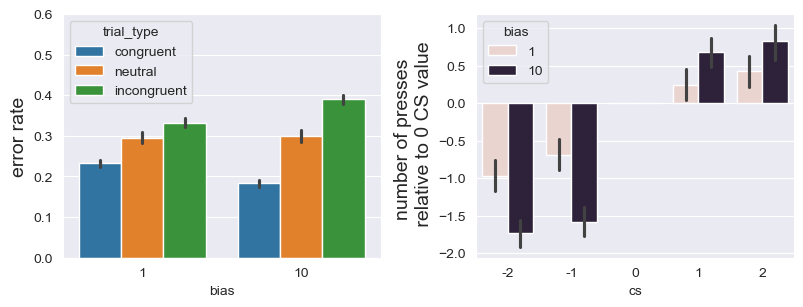

In [156]:

# df = pd.read_csv("PIT22_long.csv")
cs_volatility = df.cs_volatility.unique()
context_volatility = df.context_volatility.unique()

df["error"] = ((df["action"] == 0) & (df["shell"] > 0)) | ((df["action"] == 1) & (df["shell"] < 0)) 
df = df.query("bias == 1 | bias == 10")
for cs_vol, context_vol in product(cs_volatility, context_volatility):
	
	fig, axes = plt.subplots(1,2, figsize=(8,3), gridspec_kw={'width_ratios':[1,1]})
	plt.tight_layout()
	plt.subplots_adjust(wspace=0.3)
	df_small = df.query(f"t==0  & cs_volatility == {cs_vol} & context_volatility == {context_vol}")
	df_small["congruency"] = pd.Categorical(df_small["congruency"], categories=[1,0,-1], ordered=True)
	sns.barplot(ax=axes[0], data=df_small, x="bias", y="error", hue="congruency", palette="tab10", errorbar="ci")
	axes[0].set_ylim(0,0.6)
	axes[0].set_ylabel("error rate", fontsize=14)
	handles, labels = axes[0].get_legend_handles_labels()
	axes[0].legend(handles=handles, labels=["congruent","neutral", "incongruent"], title="trial_type", loc="upper left")

	# sns.lineplot(ax=axes[1], data=df_small, x="bias", y="error", hue="congruency", palette="tab10", errorbar="ci")
	# axes[1].set_ylim(0,0.6)
	# axes[1].set_xlim(0.2,3.5)

	
	df_small = df.query(f"t==0 & cs_volatility == {cs_vol} & context_volatility == {context_vol} & shell < 0")
	plot_df = df_small.groupby(by=["bias","sim","cs"])["samples_pi1"].mean().unstack(["cs"]).reset_index()
	shift = plot_df[0].copy()
	# display(shift)
	for c in [-2,-1,0,1,2]:
		plot_df[c] -= shift	
	plot_df = plot_df.melt(id_vars=["bias","sim"], value_vars=[-2,-1,0,1,2], var_name="cs", value_name="samples_pi1")	
	# display(plot_df)
	# sns.barplot(ax=axes[1], data=plot_df.query("bias==0"), x="cs", y="samples_pi1", errorbar="ci", color=sns.xkcd_rgb["pastel blue"])
	# axes[1].set_ylim(-2,3.5)

	# sns.barplot(ax=axes[2], data=plot_df.query("bias==1"), x="cs", y="samples_pi1", errorbar="ci", color=sns.xkcd_rgb["pastel red"])
	# axes[2].set_ylim(-2,3.5)

	# sns.barplot(ax=axes[3], data=plot_df.query("bias==1.5"), x="cs", y="samples_pi1", errorbar="ci", color=sns.xkcd_rgb["pastel green"])
	# axes[3].set_ylim(-2,3.5)

	sns.barplot(ax=axes[1], data=plot_df, x="cs", y="samples_pi1", hue="bias", errorbar="ci")
	axes[1].set_ylabel("number of presses \n relative to 0 CS value", fontsize=14)
	# plt.suptitle(f"cs_vol: {cs_vol}, context_vol: {context_vol}")




Index(['sim', 'run', 'tau', 't', 'observation', 'action', 'reward', 'bias',
       'context_volatility', 'utility_0', 'utility_1', 'utility_2', 'cs',
       'shell', 'congruency', 'cs_volatility', 'chosen_policy_samples',
       'likelihood_pi0_c0', 'likelihood_pi1_c0', 'likelihood_pi0_c1',
       'likelihood_pi1_c1', 'likelihood_pi0_c2', 'likelihood_pi1_c2',
       'likelihood_pi0_c3', 'likelihood_pi1_c3', 'likelihood_pi0_c4',
       'likelihood_pi1_c4', 'likelihood_pi0_c5', 'likelihood_pi1_c5',
       'posterior_pi0_c0', 'posterior_pi1_c0', 'posterior_pi0_c1',
       'posterior_pi1_c1', 'posterior_pi0_c2', 'posterior_pi1_c2',
       'posterior_pi0_c3', 'posterior_pi1_c3', 'posterior_pi0_c4',
       'posterior_pi1_c4', 'posterior_pi0_c5', 'posterior_pi1_c5',
       'posterior_context_c0', 'posterior_context_c1', 'posterior_context_c2',
       'posterior_context_c3', 'posterior_context_c4', 'posterior_context_c5',
       'policy_entropy_c0', 'policy_entropy_c1', 'policy_entropy_c2',
  

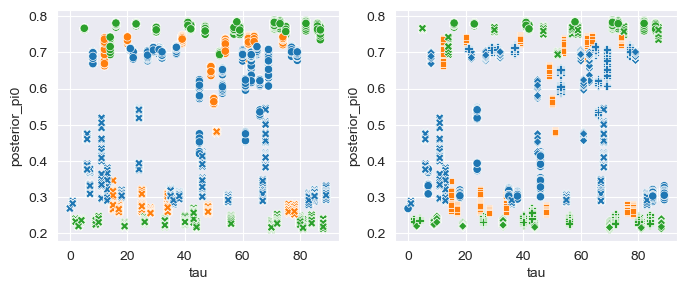

In [145]:

df = pd.read_csv("PIT22_long.csv")
print(df.columns)
cs_volatility = df.cs_volatility.unique()
context_volatility = df.context_volatility.unique()

df["error"] = ((df["action"] == 0) & (df["shell"] > 0)) | ((df["action"] == 1) & (df["shell"] < 0)) 
# df = df.query("bias == 0.5 | bias == 1.5")
for cs_vol, context_vol in product(cs_volatility, context_volatility):
	
	fig, axes = plt.subplots(1,2, figsize=(8,3), gridspec_kw={'width_ratios':[1,1]})

	sns.scatterplot(data=df.query(f"t==0 & bias == 1"),x="tau", y="posterior_pi0", hue="congruency", palette="tab10", ax=axes[0], style="shell", legend=False)
	sns.scatterplot(data=df.query(f"t==0 & bias == 1"),x="tau", y="posterior_pi0", hue="congruency", palette="tab10", ax=axes[1], style="cs", legend=False)

c:\Users\ivsi289a\AppData\Local\anaconda3\envs\dp_torch\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\ivsi289a\AppData\Local\anaconda3\envs\dp_torch\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


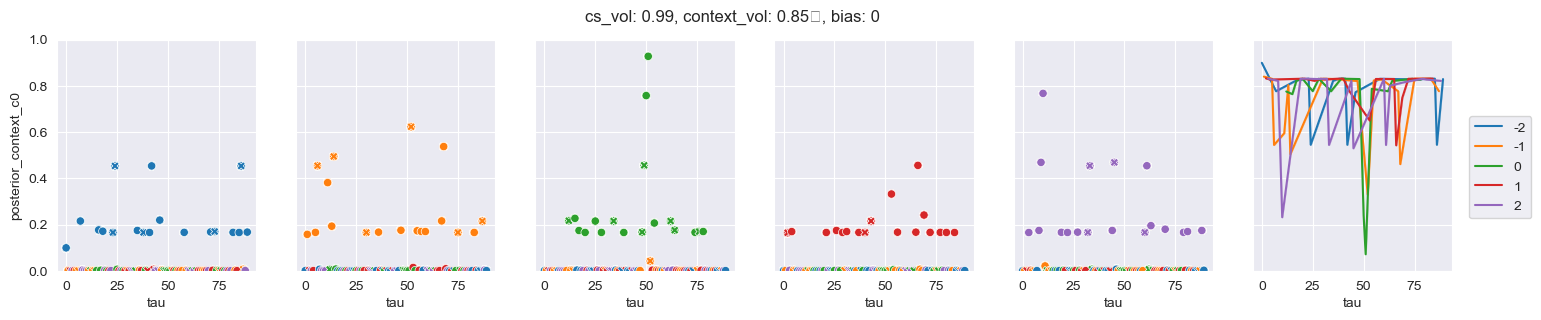

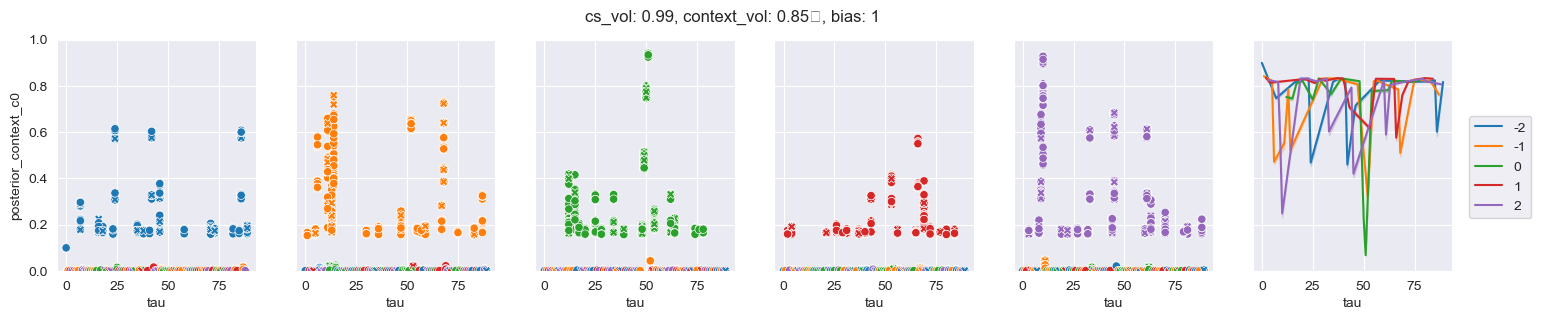

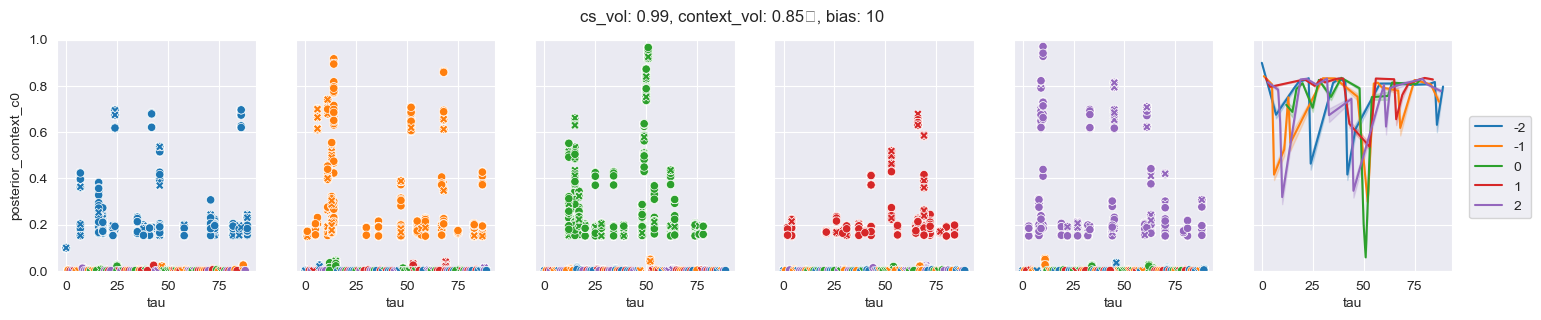

In [151]:
for bias in df.bias.unique():
	fig, axes = plt.subplots(1,6, figsize=(18,3), sharey=True)
	df_small = df.query(f"t==0  & cs_volatility == {cs_vol} & context_volatility == {context_vol} & bias == {bias}")

	for ai, ax in enumerate(axes[:-1]):
		# sns.scatterplot(ax=ax, data=df_small, x="tau", y=f"posterior_context_c{ai}", hue="cs", style="congruency", markers={0:"s", 1:"o", -1:'X'}, palette="tab10",legend=False)
		sns.scatterplot(ax=ax, data=df_small, x="tau", y=f"posterior_context_c{ai}", hue="cs", style="error", palette="tab10",legend=False)

		ax.set_ylim(0,1)

	sns.lineplot(ax=axes[-1], data=df_small, x="tau", y=f"posterior_context_c{axes.size-1}", hue="cs", errorbar="ci", palette="tab10")
	axes[-1].set_ylim(0,1)
	axes[-1].legend(bbox_to_anchor=(1.05, 0.7))
	plt.suptitle(f"cs_vol: {cs_vol}, context_vol: {context_vol}	, bias: {bias}")


In [ ]:
df.query("sim==0 & t == 0")["cs"].to_numpy()[45:55]

In [ ]:

fig, axes = plt.subplots(1,6, figsize=(18,3), sharey=True)

for ai, ax in enumerate(axes[:-1]):
	sns.scatterplot(ax=ax, data=df.query("t==0"), x="tau", y=f"posterior_context_c{ai}", hue="cs", style="congruency", markers={0:"s", 1:"o", -1:'X'}, palette="tab10",legend=False)

sns.lineplot(ax=axes[-1], data=df.query("t==0"), x="tau", y=f"posterior_context_c{axes.size-1}", hue="cs", errorbar="ci", palette="tab10")

axes[-1].legend(bbox_to_anchor=(1.05, 0.7))


In [ ]:

df = pd.read_csv("PIT222_long.csv")
cs_volatility = df.cs_volatility.unique()
context_volatility = df.context_volatility.unique()

df["error"] = ((df["action"] == 0) & (df["shell"] > 0)) | ((df["action"] == 1) & (df["shell"] < 0)) 
# df = df.query("bias == 0.5 | bias == 1.5")
for cs_vol, context_vol in product(cs_volatility, context_volatility):
	
	fig, axes = plt.subplots(1,2, figsize=(8,3), gridspec_kw={'width_ratios':[1,1]})
	plt.tight_layout()
	plt.subplots_adjust(wspace=0.3)
	df_small = df.query(f"t==0 & congruency != 0 & cs_volatility == {cs_vol} & context_volatility == {context_vol}")
	df_small["congruency"] = pd.Categorical(df_small["congruency"], categories=[1,-1], ordered=True)
	sns.barplot(ax=axes[0], data=df_small, x="bias", y="error", hue="congruency", palette="tab10", errorbar="ci")
	axes[0].set_ylim(0,0.6)
	axes[0].set_ylabel("error rate", fontsize=14)
	handles, labels = axes[0].get_legend_handles_labels()
	axes[0].legend(handles=handles, labels=["congruent", "incongruent"], title="trial_type", loc="upper left")

	# sns.lineplot(ax=axes[1], data=df_small, x="bias", y="error", hue="congruency", palette="tab10", errorbar="ci")
	# axes[1].set_ylim(0,0.6)
	# axes[1].set_xlim(0.2,3.5)

	
	# df_small = df.query(f"t==0 & cs_volatility == {cs_vol} & context_volatility == {context_vol} & shell < 0")
	# plot_df = df_small.groupby(by=["bias","sim","cs"])["samples_pi1"].mean().unstack(["cs"]).reset_index()
	# shift = plot_df[0].copy()
	# # display(shift)
	# for c in [-2,-1,0,1,2]:
	# 	plot_df[c] -= shift	
	# plot_df = plot_df.melt(id_vars=["bias","sim"], value_vars=[-2,-1,0,1,2], var_name="cs", value_name="samples_pi1")	
	# display(plot_df)
	# sns.barplot(ax=axes[1], data=plot_df.query("bias==0"), x="cs", y="samples_pi0", errorbar="ci", color=sns.xkcd_rgb["pastel blue"])
	# axes[1].set_ylim(-2,3.5)

	# sns.barplot(ax=axes[2], data=plot_df.query("bias==1"), x="cs", y="samples_pi1", errorbar="ci", color=sns.xkcd_rgb["pastel red"])
	# axes[2].set_ylim(-2,3.5)

	# sns.barplot(ax=axes[3], data=plot_df.query("bias==1.5"), x="cs", y="samples_pi1", errorbar="ci", color=sns.xkcd_rgb["pastel green"])
	# axes[3].set_ylim(-2,3.5)

	# sns.barplot(ax=axes[1], data=plot_df, x="cs", y="samples_pi1", hue="bias", errorbar="ci")
	# axes[1].set_ylabel("number of presses \n relative to 0 CS value", fontsize=14)
	# plt.suptitle(f"cs_vol: {cs_vol}, context_vol: {context_vol}")



<Axes: xlabel='shell,cs'>

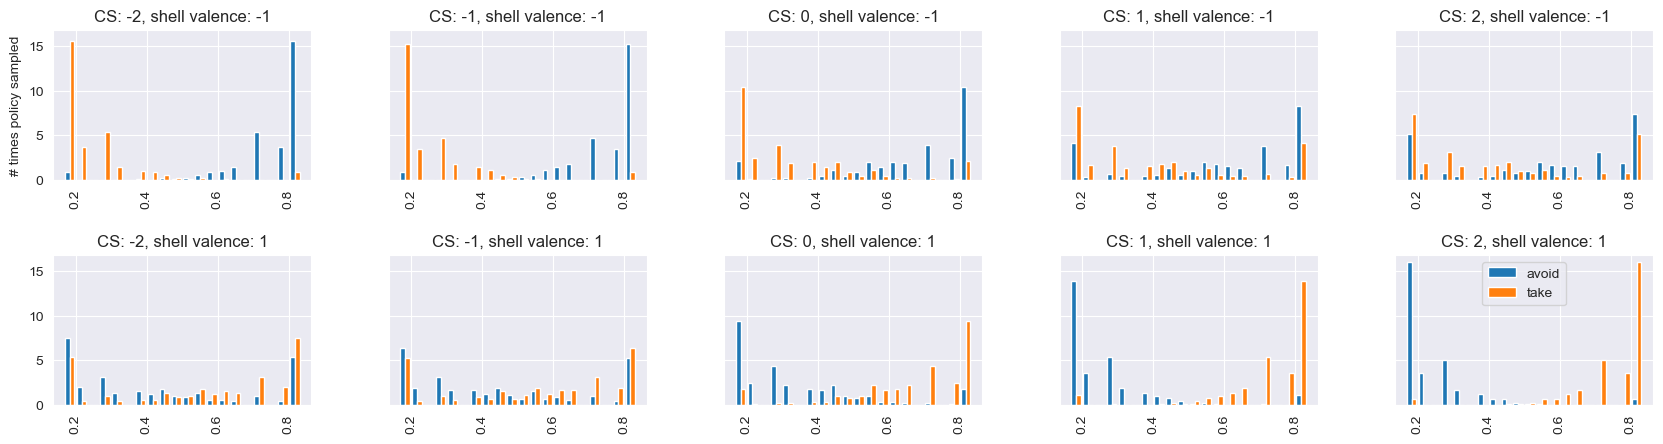

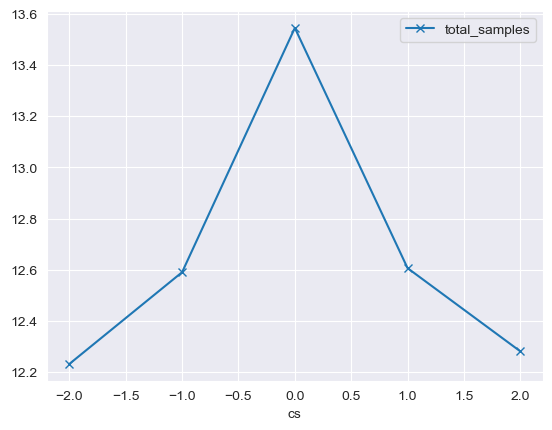

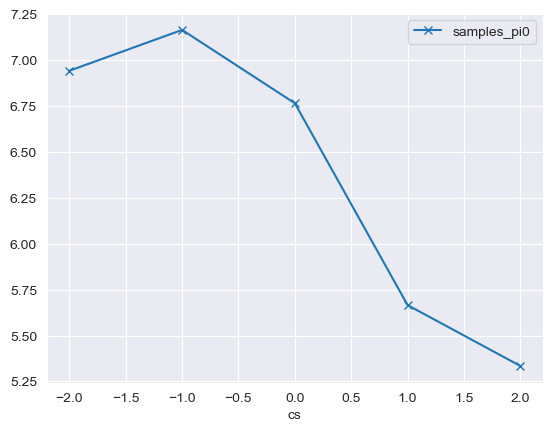

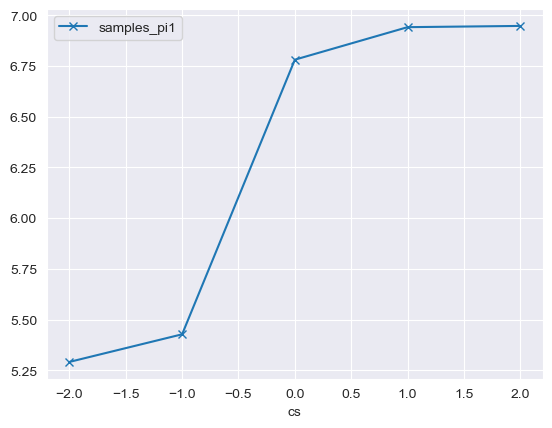

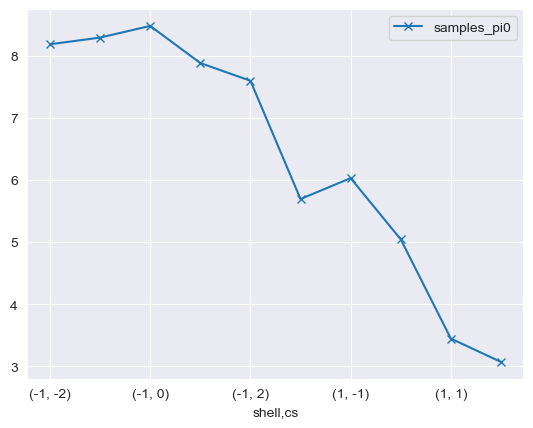

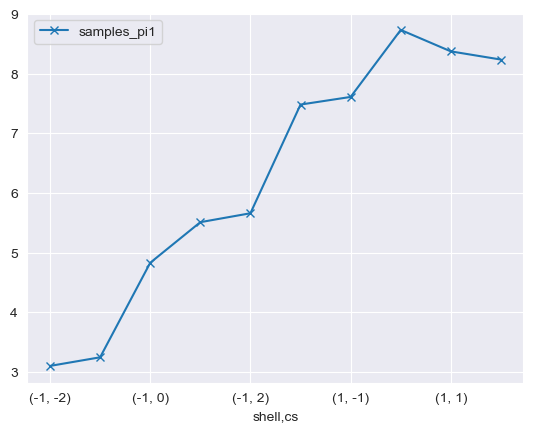

In [155]:
df = "data_PIT_90_bias1_context0.99_long.csv"
df = "PIT22_long.csv"
df = pd.read_csv(df)
df_small = df.query("t==0")[["sim","bias","cs","shell","congruency","tau","t", "action","samples_pi0","samples_pi1"]]
# df_small[["samples_pi0","samples_pi1"]] /= (df_small["samples_pi0"] + df_small["samples_pi1"])
df_small["total_samples"] = df_small["samples_pi0"] + df_small["samples_pi1"]
df_small["samples_pi0_norm"] = df_small["samples_pi0"] / df_small["total_samples"]
df_small["samples_pi1_norm"] = df_small["samples_pi1"] / df_small["total_samples"]

df_small = df_small.query("bias==10")
axes = df_small.hist(column=["samples_pi0_norm","samples_pi1_norm"], by=["shell","cs"], legend=False, sharey=True, layout=(2,5),figsize=(20,5), density=True, bins=20)
for ax in axes.flatten():
	vals = [int(val) for val in ax.get_title()[1:-1].split(", ")]
	ax.set_title(f"CS: {vals[-1]}, shell valence: {vals[0]}")
axes[0,0].set_ylabel("# times policy sampled")
plt.legend(labels=["avoid", "take"])


df_small.groupby(by=["cs"])[["total_samples"]].mean().plot(marker="x")
df_small.groupby(by=["cs"])[["samples_pi0"]].mean().plot(marker="x")
df_small.groupby(by=["cs"])[["samples_pi1"]].mean().plot(marker="x")

df_small.groupby(by=["shell","cs"])[["samples_pi0"]].mean().plot(marker="x")
df_small.groupby(by=["shell","cs"])[["samples_pi1"]].mean().plot(marker="x")



In [ ]:
df_small = df.query("t==0")
df_small["total_samples"] = df_small["samples_pi0"] + df_small["samples_pi1"]
df_small["samples_pi0_norm"] = df_small["samples_pi0"] / df_small["total_samples"]
df_small["samples_pi1_norm"] = df_small["samples_pi1"] / df_small["total_samples"]


df_small[["samples_pi0_norm","samples_pi1_norm", "total_samples", "samples_pi0", "samples_pi1"]].head(50)
df_small.query("shell == 1 & cs == 1").hist(column=["samples_pi0_norm","samples_pi1_norm"], legend=True, bins=30)
df_small.query("shell == 1 & cs == 1 & samples_pi0_norm > 0.7")[["samples_pi0_norm","samples_pi1_norm", "total_samples", "samples_pi0", "samples_pi1"]]

In [ ]:
df_small = df.query("t==0")
df_small["total_samples"] = df_small["samples_pi0"] + df_small["samples_pi1"]
df_small["samples_pi0_norm"] = df_small["samples_pi0"] / df_small["total_samples"]
df_small["samples_pi1_norm"] = df_small["samples_pi1"] / df_small["total_samples"]


df_small.query("shell == 1 & cs == 1").iloc[:5][["samples_pi0_norm","samples_pi1_norm", "total_samples", "samples_pi0", "samples_pi1"]]

#### Run simulations